In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_index = pd.read_csv('economic_index.csv')

In [3]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df_index.drop(columns = ['Unnamed: 0','year','month'],inplace = True)

In [5]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

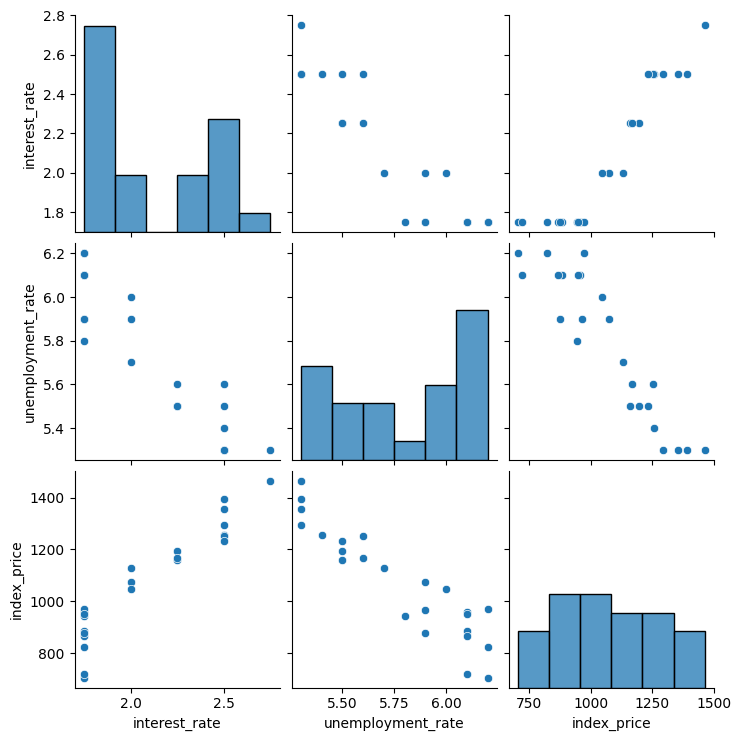

In [7]:
import seaborn as sns
sns.pairplot(df_index)

In [8]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0.5, 1.0, 'Interest Rate vs Unemployment Rate')

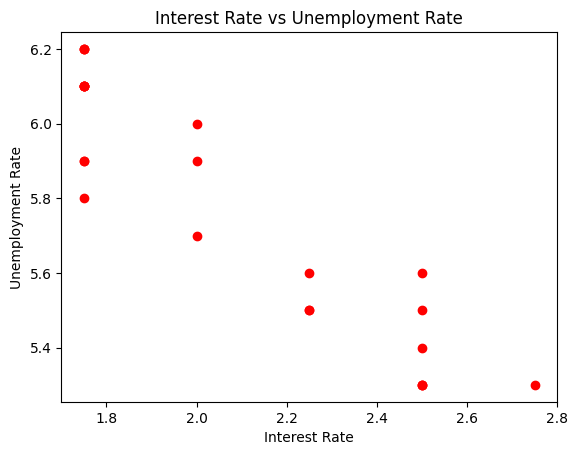

In [9]:
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.title('Interest Rate vs Unemployment Rate')

In [10]:
## Get Independent and Dependent Features
X = df_index[['interest_rate','unemployment_rate']]
y = df_index['index_price']

In [11]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

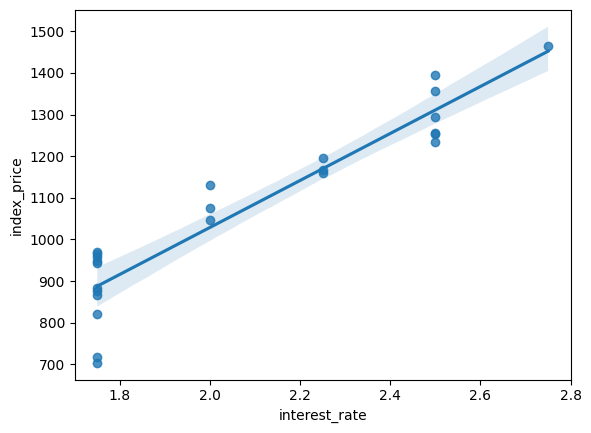

In [12]:
sns.regplot(x = df_index['interest_rate'],y = df_index['index_price'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

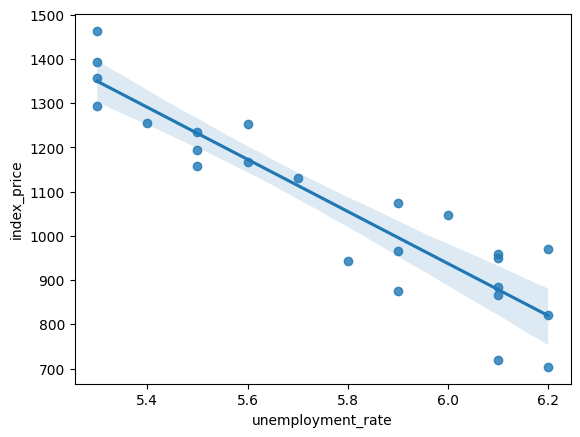

In [13]:
sns.regplot(x = df_index['unemployment_rate'],y = df_index['index_price'])

In [14]:
# Standardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(lr,X_train,y_train,scoring = 'neg_mean_squared_error', cv=5)

In [17]:
validation_score

array([-1606.47408206, -9579.95329208, -7961.60935985, -8392.32547433,
        -773.2668524 ])

In [18]:
np.mean(validation_score)

np.float64(-5662.72581214445)

In [19]:
##Predicting on Test Data
y_pred = lr.predict(X_test)

In [20]:
print("Regression coefficients:", lr.coef_)

Regression coefficients: [  86.63351334 -114.04857249]


In [21]:
## Evaluating the Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)   
print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)
print("Adjusted R^2 Score:", 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

Mean Absolute Error: 71.71878409976625
Mean Squared Error: 6957.105303258833
Root Mean Squared Error: 83.40926389351985
R^2 Score: 0.8254940547158576
Adjusted R^2 Score: 0.6509881094317151


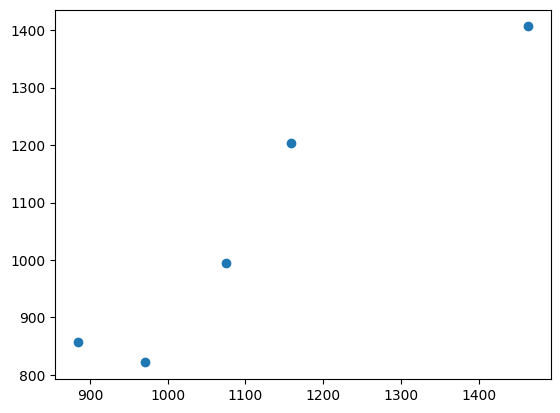

In [22]:
##Assumptions of Linear Regression
plt.scatter(y_test, y_pred)

In [23]:
residuals = y_test - y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


<Axes: xlabel='index_price', ylabel='Density'>

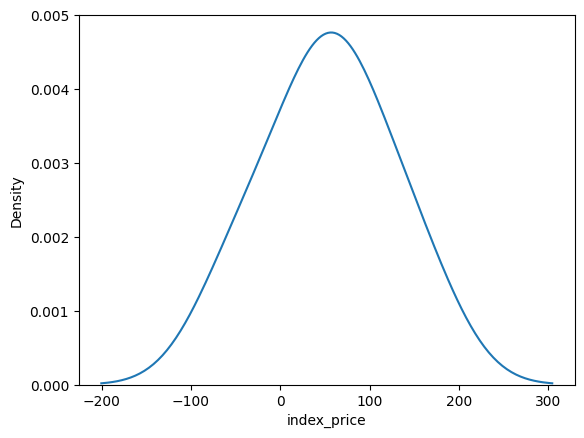

In [24]:
sns.kdeplot(residuals)

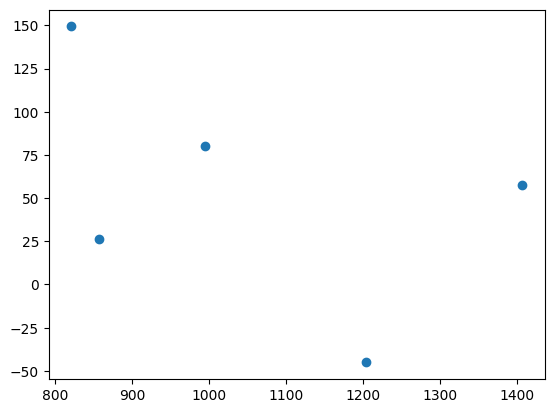

In [25]:
plt.scatter(y_pred, residuals)

In [26]:
##OLS Summary
import statsmodels.api as sm
X_sm_train = sm.add_constant(X_train)
X_sm_test = sm.add_constant(X_test)
model = sm.OLS(y_train, X_sm_train).fit()

In [27]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            index_price   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.893
Method:                 Least Squares   F-statistic:                     75.80
Date:                Wed, 31 Dec 2025   Prob (F-statistic):           6.90e-09
Time:                        12:32:35   Log-Likelihood:                -105.94
No. Observations:                  19   AIC:                             217.9
Df Residuals:                      16   BIC:                             220.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1059.4211     15.966     66.356      0.0

c:\Users\Abhis\OneDrive\Desktop\Projects\Intelligent Support System\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=19 observations were given.
  return hypotest_fun_in(*args, **kwds)
